# Supply Chain Control Tower — EDA

Exploratory analysis on the **real Olist** order data (98,666 orders) that motivates the
KPI design, supplier risk score, and dashboard. Run `python src/run_pipeline.py` first so
the marts and DuckDB database exist.

**Roadmap:** data overview → fulfillment timing → the late→satisfaction link →
geographic risk → revenue concentration (ABC) → supplier risk distribution.

In [1]:
import duckdb, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
con = duckdb.connect('../data/processed/control_tower.duckdb', read_only=True)
q = lambda s: con.execute(s).df()
q("SELECT COUNT(*) AS orders, COUNT(DISTINCT primary_supplier_id) AS suppliers, "
  "COUNT(DISTINCT region_state) AS regions, MIN(order_ts) AS first_order, MAX(order_ts) AS last_order "
  "FROM fact_orders")

,orders,suppliers,regions,first_order,last_order
0,98666,3086,27,2016-09-04 21:15:19,2018-09-03 09:06:57


## 1. Order status & delivery completeness
Most orders are delivered; we compute service KPIs on delivered orders only.

In [2]:
q("SELECT order_status, COUNT(*) AS n, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),2) AS pct "
  "FROM fact_orders GROUP BY 1 ORDER BY n DESC")

,order_status,n,pct
0,delivered,96478,97.780
1,shipped,1106,1.120
2,canceled,461,0.470
3,invoiced,312,0.320
4,processing,301,0.310
5,unavailable,6,0.010
6,approved,2,0.000


## 2. Headline KPIs
The single source of truth used across the README and memo (`mart_exec_kpis`).

In [3]:
q("SELECT * FROM mart_exec_kpis")

,kpi,value
0,total_orders,"98,666.000"
1,delivered_orders,"96,470.000"
2,total_revenue_brl,"13,591,643.700"
3,total_freight_brl,"2,251,909.540"
4,freight_to_revenue,0.166
5,on_time_rate,0.932
6,late_rate,0.068
7,avg_delay_days_late,10.620
8,cancel_rate,0.005
9,bad_review_rate,0.146


## 3. The money insight: does late delivery hurt satisfaction?
This is the finding that reframes the whole project — on-time delivery as a *revenue* KPI.

In [4]:
sat = q("""SELECT CASE WHEN is_late THEN 'late' ELSE 'on_time' END AS bucket,
       COUNT(*) AS orders, ROUND(AVG(review_score),2) AS avg_review,
       ROUND(AVG(CASE WHEN is_bad_review THEN 1.0 ELSE 0 END),3) AS bad_review_rate
FROM fact_orders WHERE is_delivered AND review_score IS NOT NULL GROUP BY 1 ORDER BY 1""")
print('Late orders are', round(sat.bad_review_rate.max()/sat.bad_review_rate.min(),1),
      'x more likely to get a 1-2 star review')
sat

Late orders are 6.6 x more likely to get a 1-2 star review


,bucket,orders,avg_review,bad_review_rate
0,late,6534,2.250,0.629
1,on_time,89936,4.280,0.096


## 4. Geographic risk
Late rate varies ~4x across states; volume × late-rate identifies the highest-impact regions.

In [5]:
reg = q("SELECT region_state, orders, late_rate, avg_delay_days_late, bad_review_rate "
        "FROM mart_region WHERE orders>=500 ORDER BY late_rate DESC")
reg['impact_late_orders'] = (reg.orders*reg.late_rate).round(0)
reg.head(8)

,region_state,orders,late_rate,avg_delay_days_late,bad_review_rate,impact_late_orders
0,MA,740,0.174,10.504,0.222,129.000
1,CE,1327,0.138,15.182,0.197,183.000
2,BA,3358,0.122,12.023,0.193,408.000
3,RJ,12762,0.121,13.522,0.209,"1,545.000"
4,PA,970,0.112,12.821,0.201,109.000
5,ES,2025,0.107,11.299,0.155,217.000
6,PB,532,0.104,10.333,0.167,56.000
7,MS,709,0.097,8.338,0.140,69.000


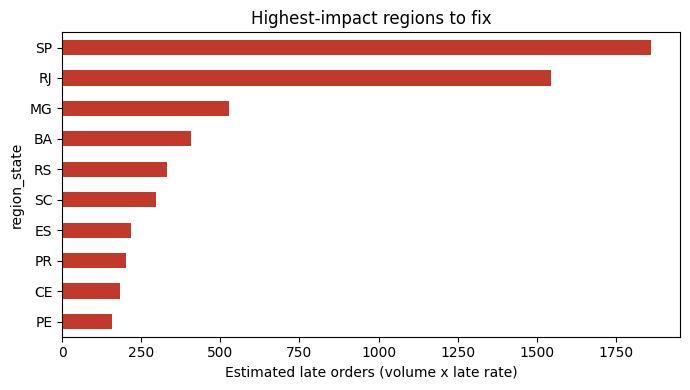

In [6]:
top = reg.sort_values('impact_late_orders', ascending=False).head(10)
ax = top.plot.barh(x='region_state', y='impact_late_orders', legend=False, color='#c0392b', figsize=(7,4))
ax.invert_yaxis(); ax.set_xlabel('Estimated late orders (volume x late rate)')
ax.set_title('Highest-impact regions to fix'); plt.tight_layout(); plt.show()

## 5. Revenue concentration (ABC)
A small set of categories drives most revenue — focus margin/quality work there.

In [7]:
q("SELECT abc_class, COUNT(*) AS categories, ROUND(SUM(revenue_share),3) AS revenue_share "
  "FROM mart_product_risk GROUP BY 1 ORDER BY 1")

,abc_class,categories,revenue_share
0,A,17,0.796
1,B,16,0.152
2,C,41,0.051


## 6. Supplier risk distribution
Risk is concentrated: the worst quintile carries outsized revenue at ~2x the platform failure rates.

In [8]:
q("""SELECT risk_quintile, COUNT(*) AS suppliers, ROUND(SUM(revenue),0) AS revenue,
       ROUND(AVG(late_rate),3) AS avg_late, ROUND(AVG(bad_review_rate),3) AS avg_bad
FROM mart_supplier_scorecard GROUP BY 1 ORDER BY 1 DESC""")

,risk_quintile,suppliers,revenue,avg_late,avg_bad
0,5,163,"2,698,525.000",0.122,0.238
1,4,163,"2,927,650.000",0.088,0.172
2,3,164,"1,999,883.000",0.059,0.142
3,2,164,"1,964,174.000",0.043,0.104
4,1,164,"1,572,319.000",0.018,0.074


## Takeaways
1. **Late delivery is the dominant satisfaction driver** (6.5x bad-review rate) → treat on-time as a revenue KPI.
2. **Risk is geographic** → prioritize RJ + Northeast by impact, not raw late rate.
3. **Revenue and supplier risk are both concentrated** → a focused intervention list beats broad effort.

These observations drive the [supplier risk score](../docs/kpi_dictionary.md) and the
[Looker Studio dashboard](../dashboard/looker_studio_build_guide.md).